# HAL-TMLE for Right-Censored Survival Targets

This notebook is now a thin demo wrapper around the package API for right-censored survival targeting.

Locked design choices:
- fit one reverse Kaplan-Meier from observed data `(tilde T, Delta)` and reuse the same fitted KM object throughout;
- keep the existing IPCW HAL initializer unchanged;
- compute one pointwise scalar update per target time `t0`;
- use an augmented quadrature grid for each `t0`;
- estimate pointwise survival variance through the empirical EIC.


In [14]:
import os
import sys
import pathlib
from dataclasses import dataclass
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq, minimize_scalar

ROOT = pathlib.Path.cwd().resolve()
for candidate in [ROOT, ROOT.parent, ROOT.parent.parent]:
    src_path = candidate / 'src'
    if src_path.exists() and str(src_path) not in sys.path:
        sys.path.append(str(src_path))

os.environ.setdefault('MPLCONFIGDIR', str((ROOT / '.matplotlib').resolve()))

from haldensity.censoring.right.km import KaplanMeier
from haldensity.censoring.right.weights import compute_ipcw_weights
from haldensity.censoring.right.estimators import RightCensoredInitEstimator
from haldensity.censoring.tuners.right_tuners import RightCensoredInitTuner
from haldensity.utils import TruncatedGMM

from haldensity.targeting import (
    RightCensoredSurvivalTargetLearner,
    right_censored_survival_targeting_M_step,
    right_censored_survival_estimand_variance,
)


## Setup and Evaluation Conventions

We work with observed data `(tilde T, Delta)` where `tilde T = min(T, C)` and `Delta = I(T <= C)`.
The Stage 1 fit follows the same IPCW convention and estimator path as the current right-censoring workflow, but the notebook manually refits the tuned initializer so the package targeting API can reuse the same fitted KM object.

Implementation conventions used throughout this demo:
- use right-continuous `\bar G_n(t)` in every denominator appearing in `D_{F_n,G_n}` where the derivation specifies `\bar G(t)`;
- keep the repo's existing Stage 1 IPCW convention unchanged;
- for each pointwise TMLE problem, start from the stored HAL grid and augment the quadrature breakpoints with the current target time `t0`;
- evaluate density and the fluctuation direction on the resulting pointwise midpoint grid;
- compute survival from edge-based suffix sums on that augmented grid using `delta_j`;
- estimate pointwise variance by the empirical variance of the EIC divided by `n`.


In [15]:
RNG_SEED = 42
N = 180
CV_FOLDS = 5
N_TRIALS = 20  # keep the demo quick; increase for a more stable Stage 1 fit
N_GRID_POINTS = 200
BASIS_ORDER_OPTIONS = [2]
GBAR_CLIP = 1e-6
SURVIVAL_CLIP = 1e-8
EPS_BRACKET_START = 0.25
EPS_BRACKET_GROWTH = 2.0
EPS_BRACKET_MAX = 16.0
EPS_FALLBACK_BOUNDS = (-50.0, 50.0)
TARGET_TIMES = np.linspace(0.05, 0.95, 20)
FOCUS_T0 = 0.5
np.random.seed(RNG_SEED)


In [16]:
# 1) Generate synthetic right-censored data
sampler_params = {
    'components': [
        {'mean': 0.2, 'std': 0.05, 'lower': 0, 'upper': 1},
        {'mean': 0.5, 'std': 0.05, 'lower': 0, 'upper': 1},
        {'mean': 0.8, 'std': 0.05, 'lower': 0, 'upper': 1},
    ],
    'weights': [0.33, 0.34, 0.33],
}
sampler = TruncatedGMM(**sampler_params)
event_times = sampler.generate_samples(N)
censor_times = np.random.uniform(0, 1, size=N)
tilde_T = np.minimum(event_times, censor_times)
Delta = (event_times <= censor_times).astype(int)
data = pd.DataFrame({'T': tilde_T, 'Delta': Delta})

print(f'n={N}, uncensored={Delta.sum()}, censored={N - Delta.sum()}')
print(f'censoring rate: {1 - Delta.mean():.1%}')
data.head()


n=180, uncensored=95, censored=85
censoring rate: 47.2%


,T,Delta
0,0.528144,1
1,0.435673,0
2,0.481872,1
3,0.047716,0
4,0.440205,1


In [17]:
# 2) Tune Stage 1, then refit Stage 1 manually with one KM object shared with the TMLE layer
init_tuner = RightCensoredInitTuner(
    data=data,
    cv_folds=CV_FOLDS,
    n_grid_points=N_GRID_POINTS,
    silent=True,
)
init_tuner.param_overrides = {'basis_order': BASIS_ORDER_OPTIONS}
tuned_init = init_tuner.optimize(n_trials=N_TRIALS)

km_shared = KaplanMeier().fit(data, time_col='T', delta_col='Delta')
shared_weights = compute_ipcw_weights(
    T=data['T'].to_numpy(),
    Delta=data['Delta'].to_numpy(),
    S_c_predict=lambda t: np.atleast_1d(km_shared.predict(t)),
    clip=GBAR_CLIP,
)
uncensored_mask = data['Delta'].to_numpy() == 1
uncensored_df = pd.DataFrame({'W1': data.loc[uncensored_mask, 'T'].to_numpy()})

stage1_estimator = RightCensoredInitEstimator(
    tol=tuned_init.estimator.tol,
    norm_constraint=float(tuned_init.best_params['norm_constraint']),
    n_grid_points=N_GRID_POINTS,
    basis_order=int(tuned_init.best_params['basis_order']),
    solver=tuned_init.estimator.solver,
    use_secondary_solver=tuned_init.estimator.use_secondary_solver,
)
stage1_estimator.fit(uncensored_df, sample_weights=shared_weights[uncensored_mask])

print('Stage 1 tuning best params:', tuned_init.best_params)
print('Stage 1 selected knots:', int(stage1_estimator.get_results()['n_selected_knots']))
print('KM shared between Stage 1 refit and TMLE layer:', isinstance(km_shared, KaplanMeier))


Stage 1 tuning best params: {'norm_constraint': 963.3551080156752, 'basis_order': 2}
Stage 1 selected knots: 21
KM shared between Stage 1 refit and TMLE layer: True


In [ ]:
# 3) The right-censored TMLE logic now lives in the package API imported above
learner = RightCensoredSurvivalTargetLearner(
    clip=GBAR_CLIP,
    survival_clip=SURVIVAL_CLIP,
    eps_bracket_start=EPS_BRACKET_START,
    eps_bracket_growth=EPS_BRACKET_GROWTH,
    eps_bracket_max=EPS_BRACKET_MAX,
    eps_fallback_bounds=EPS_FALLBACK_BOUNDS,
)


In [ ]:
# 4) Run one pointwise targeted fit for the focus time through the package API
focus_targeted = right_censored_survival_targeting_M_step(
    initial_estimator=stage1_estimator,
    observed_data=data,
    targeting_points=FOCUS_T0,
    km=km_shared,
    clip=GBAR_CLIP,
    survival_clip=SURVIVAL_CLIP,
    eps_bracket_start=EPS_BRACKET_START,
    eps_bracket_growth=EPS_BRACKET_GROWTH,
    eps_bracket_max=EPS_BRACKET_MAX,
    eps_fallback_bounds=EPS_FALLBACK_BOUNDS,
    store_pointwise_arrays=True,
)
focus_result = focus_targeted['pointwise_fits'][0]
focus_initial_fit = focus_targeted['initial_fit']
focus_censoring_cache = focus_targeted['censoring_cache']


In [ ]:
pd.Series({
    "t0": focus_result['t0'],
    "psi_init": focus_result['psi_init'],
    "psi_star": focus_result['psi_star'],
    "epsilon": focus_result['epsilon'],
    "standard_error": focus_result['standard_error'],
    "ci_lower": focus_result['ci_lower'],
    "ci_upper": focus_result['ci_upper'],
    "score_at_zero": focus_result['score_at_zero'],
    "score_at_solution": focus_result['score_at_solution'],
    "solve_method": focus_result['solve_method'],
    "eif_mean": focus_result['eif_mean'],
    "converged": focus_result['converged'],
})


In [ ]:
# 5) KM and direction diagnostics for one target time
focus_details = focus_result['diagnostics']['direction_details']
grid = focus_result['target_grid_midpoints']
gbar_right_grid = focus_result['diagnostics']['gbar_right_on_target_grid']
gbar_left_grid = focus_result['diagnostics']['gbar_left_on_target_grid']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].step(focus_censoring_cache['jump_times'], focus_censoring_cache['gbar_right'], where='post', label='Gbar(t)', color='tab:blue')
axes[0, 0].step(focus_censoring_cache['jump_times'], focus_censoring_cache['gbar_left'], where='post', label='Gbar(t-)', color='tab:orange')
axes[0, 0].axvline(FOCUS_T0, color='tab:red', linestyle='--', label='t0')
axes[0, 0].set_title('KM right and left limits at jumps')
axes[0, 0].legend()

axes[0, 1].bar(focus_censoring_cache['jump_times'], focus_censoring_cache['jump_masses'], width=0.01, color='tab:green')
axes[0, 1].axvline(FOCUS_T0, color='tab:red', linestyle='--')
axes[0, 1].set_title('Censoring jump masses')
axes[0, 1].set_xlabel('time')

axes[1, 0].plot(grid, focus_details['first_term_grid'], label='first term', color='tab:blue')
axes[1, 0].plot(grid, focus_details['cumulative_jump_term_grid'], label='cumulative jump term', color='tab:orange')
axes[1, 0].axvline(FOCUS_T0, color='tab:red', linestyle='--')
axes[1, 0].set_title('Direction building blocks on the pointwise grid (using Gbar(t))')
axes[1, 0].legend()

axes[1, 1].plot(grid, focus_result['raw_direction'], label='raw D', color='tab:purple')
axes[1, 1].plot(grid, focus_result['centered_direction'], label='centered D', color='tab:green')
axes[1, 1].axvline(FOCUS_T0, color='tab:red', linestyle='--')
axes[1, 1].set_title('Raw vs centered direction')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print({
    "gbar_convention": focus_details['gbar_convention'],
    "stage1_ipcw_convention": focus_details['stage1_ipcw_convention'],
    "target_grid_augmented_with_t0": focus_result['target_grid_augmented_with_t0'],
    "n_target_intervals": len(grid),
    "gbar_t0_right": focus_details['gbar_t0_right'],
})
jump_check = pd.DataFrame({
    "jump_time": focus_censoring_cache['jump_times'],
    "gbar_t": focus_censoring_cache['gbar_right'],
    "gbar_t_minus": focus_censoring_cache['gbar_left'],
    "gap": focus_censoring_cache['gbar_left'] - focus_censoring_cache['gbar_right'],
})
print(jump_check.head(10).to_string(index=False))


In [ ]:
# 6) Inspect the scalar objective and score for one target time
eps_grid = focus_result['diagnostics']['diagnostic_eps_grid']
ll_values = focus_result['diagnostics']['diagnostic_loglik_values']
score_values = focus_result['diagnostics']['diagnostic_score_values']
solver_details = focus_result['diagnostics']['solver_details']
print({
    "score_at_zero": focus_result['score_at_zero'],
    "score_at_solution": focus_result['score_at_solution'],
    "solve_method": focus_result['solve_method'],
    "bracket": solver_details.get('bracket'),
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(eps_grid, ll_values, color='tab:blue')
axes[0].axvline(focus_result['epsilon'], color='tab:red', linestyle='--', label='epsilon_hat')
axes[0].set_title('Observed-data log-likelihood')
axes[0].set_xlabel('epsilon')
axes[0].set_ylabel('log-likelihood')
axes[0].legend()

axes[1].plot(eps_grid, score_values, color='tab:orange')
axes[1].axhline(0.0, color='black', linewidth=1)
axes[1].axvline(focus_result['epsilon'], color='tab:red', linestyle='--', label='epsilon_hat')
axes[1].set_title('Scalar targeting score')
axes[1].set_xlabel('epsilon')
axes[1].set_ylabel('score')
axes[1].legend()
plt.tight_layout()
plt.show()


In [ ]:
# 7) Compare densities before and after pointwise targeting at three target times
density_t0_values = np.array([0.25, FOCUS_T0, 0.75], dtype=float)
density_targeted = right_censored_survival_targeting_M_step(
    initial_estimator=stage1_estimator,
    observed_data=data,
    targeting_points=density_t0_values,
    km=km_shared,
    clip=GBAR_CLIP,
    survival_clip=SURVIVAL_CLIP,
    eps_bracket_start=EPS_BRACKET_START,
    eps_bracket_growth=EPS_BRACKET_GROWTH,
    eps_bracket_max=EPS_BRACKET_MAX,
    eps_fallback_bounds=EPS_FALLBACK_BOUNDS,
    store_pointwise_arrays=True,
)
density_results = {float(fit['t0']): fit for fit in density_targeted['pointwise_fits']}

print(
    "Each panel below is a separate pointwise TMLE submodel. "
    "If TARGET_TIMES has 20 values, the API computes 20 separate pointwise tilts and 20 separate psi_star values."
)

fig, axes = plt.subplots(1, len(density_t0_values), figsize=(18, 5), sharey=True)
density_summary_rows = []
for ax, density_t0 in zip(axes, density_t0_values):
    result = density_results[float(density_t0)]
    density_grid = result['target_grid_midpoints']
    density_before = result['density_before_grid']
    density_after = result['estimated_density']
    true_density_on_grid = sampler.compute_density(density_grid)
    ax.plot(density_grid, density_before, label='Stage 1 density', linewidth=2)
    ax.plot(density_grid, density_after, label='Targeted density', linewidth=2)
    ax.plot(density_grid, true_density_on_grid, label='True density', linestyle='--', linewidth=2)
    ax.set_title(
        f't0={density_t0:.2f}\n'
        f'augmented={result["target_grid_augmented_with_t0"]}, epsilon={result["epsilon"]:.4f}'
    )
    ax.set_xlabel('t')
    ax.grid(alpha=0.3)
    density_summary_rows.append({
        "t0": float(density_t0),
        "psi_init": result['psi_init'],
        "psi_star": result['psi_star'],
        "epsilon": result['epsilon'],
        "standard_error": result['standard_error'],
        "ci_lower": result['ci_lower'],
        "ci_upper": result['ci_upper'],
        "target_grid_augmented_with_t0": result['target_grid_augmented_with_t0'],
        "n_target_intervals": len(result['target_delta_j']),
    })
axes[0].set_ylabel('Density')
axes[0].legend()
fig.suptitle('Density before and after pointwise targeting at t0 = 0.25, 0.50, 0.75')
plt.tight_layout()
plt.show()

pd.DataFrame(density_summary_rows)


In [ ]:
# 8) Target a small grid of survival times through the package API
curve_targeted = right_censored_survival_targeting_M_step(
    initial_estimator=stage1_estimator,
    observed_data=data,
    targeting_points=TARGET_TIMES,
    km=km_shared,
    clip=GBAR_CLIP,
    survival_clip=SURVIVAL_CLIP,
    eps_bracket_start=EPS_BRACKET_START,
    eps_bracket_growth=EPS_BRACKET_GROWTH,
    eps_bracket_max=EPS_BRACKET_MAX,
    eps_fallback_bounds=EPS_FALLBACK_BOUNDS,
    store_pointwise_arrays=False,
)
curve_summary = curve_targeted['summary']
curve_results = curve_targeted['pointwise_fits']
curve_variances = right_censored_survival_estimand_variance(curve_targeted, observed_data=data)
curve_summary


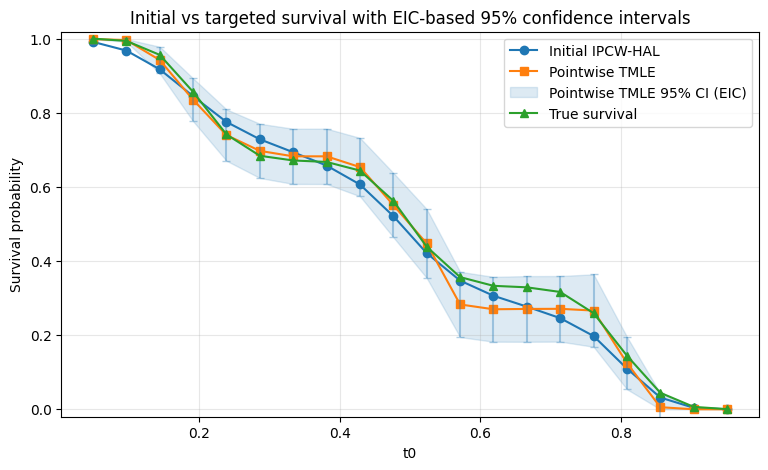

In [25]:
# 6) Compare initial, targeted, and true survival on the target grid
fine_grid = np.linspace(0.001, 0.999, 4000)
fine_delta = np.diff(np.linspace(0.0, 1.0, 4001))
true_density_fine = sampler.compute_density(fine_grid)
true_survival_fine = np.cumsum((true_density_fine * fine_delta)[::-1])[::-1]
true_survival_target = np.interp(TARGET_TIMES, fine_grid, true_survival_fine, left=1.0, right=0.0)

plt.figure(figsize=(9, 5))
plt.plot(TARGET_TIMES, curve_summary['psi_init'], marker='o', label='Initial IPCW-HAL')
plt.plot(TARGET_TIMES, curve_summary['psi_star'], marker='s', label='Pointwise TMLE')
plt.fill_between(
    TARGET_TIMES,
    curve_summary['ci_lower'],
    curve_summary['ci_upper'],
    color='tab:blue',
    alpha=0.15,
    label='Pointwise TMLE 95% CI (EIC)',
)
plt.errorbar(
    TARGET_TIMES,
    curve_summary['psi_star'],
    yerr=1.96 * curve_summary['standard_error'],
    fmt='none',
    ecolor='tab:blue',
    alpha=0.35,
    capsize=3,
)
plt.plot(TARGET_TIMES, true_survival_target, marker='^', label='True survival')
plt.xlabel('t0')
plt.ylabel('Survival probability')
plt.title('Initial vs targeted survival with EIC-based 95% confidence intervals')
plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.show()


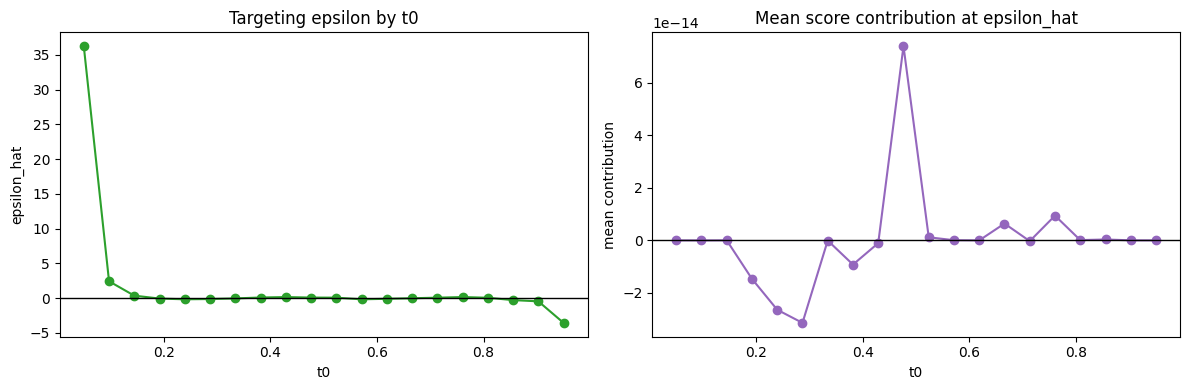

n_targets                    2.000000e+01
n_converged                  2.000000e+01
max_standard_error           4.990863e-02
max_abs_eif_mean             7.391001e-14
max_abs_score_at_solution    1.330380e-11
n_score_roots                1.900000e+01
n_fallback_optimizations     1.000000e+00
dtype: float64

In [26]:
# 7) Diagnostics across target times
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(curve_summary['t0'], curve_summary['epsilon'], marker='o', color='tab:green')
axes[0].axhline(0.0, color='black', linewidth=1)
axes[0].set_title('Targeting epsilon by t0')
axes[0].set_xlabel('t0')
axes[0].set_ylabel('epsilon_hat')

axes[1].plot(curve_summary['t0'], curve_summary['eif_mean'], marker='o', color='tab:purple')
axes[1].axhline(0.0, color='black', linewidth=1)
axes[1].set_title('Mean score contribution at epsilon_hat')
axes[1].set_xlabel('t0')
axes[1].set_ylabel('mean contribution')
plt.tight_layout()
plt.show()

pd.Series({
    'n_targets': int(len(curve_summary)),
    'n_converged': int(curve_summary['converged'].sum()),
    'max_standard_error': float(np.max(curve_summary['standard_error'])),
    'max_abs_eif_mean': float(np.max(np.abs(curve_summary['eif_mean']))),
    'max_abs_score_at_solution': float(np.max(np.abs(curve_summary['score_at_solution']))),
    'n_score_roots': int((curve_summary['solve_method'] == 'score_root').sum()),
    'n_fallback_optimizations': int((curve_summary['solve_method'] == 'bounded_fallback').sum()),
})


## Notes

This notebook is now a thin demo wrapper around the package API for right-censored survival TMLE. The package implementation intentionally keeps the IPCW initializer untouched and localizes new work to targeting helpers that:
- reuse the same fitted KM object from the Stage 1 refit;
- extract right limits, left limits, and jump masses from that KM fit, while using right-continuous `\bar G_n(t)` in the TMLE direction itself;
- build a pointwise quadrature grid for each `t0` by augmenting the stored HAL breakpoints with that target time;
- evaluate the pointwise direction and scalar TMLE likelihood on that augmented grid;
- center the direction before building the exponential tilt;
- estimate pointwise survival variance by the empirical variance of the EIC divided by `n`.

If you target a single time `t0 = 0.5`, the update is only for `S(0.5)` and the associated tilted density for that one submodel. If you target `TARGET_TIMES = np.linspace(0.05, 0.95, 20)`, the API performs 20 separate scalar updates, yielding 20 different `\psi^*(t0)` values and, in general, 20 different pointwise tilted densities.

The resulting pointwise targeted curve need not be monotone in `t0`, because each target time receives its own scalar update.
